 # Intro
 This code is used to generate figures 2,3, 4 and 10 of In-Context Learning for Discrete Optimal Transport: Can Transformers Sort? by Hadi Daneshmand accepted for a spotlight presentation at AISTATS 2026.

In [1]:
import numpy as np
from matplotlib import pyplot as plt

In [2]:
#!pip install POT # the code requires installing POT lib for computing optimal transport

# Figure 3 and 4: A transfomer which provably solves ot

Here, we design a transformer that can provably solve OT in 1 dimension which basically casts to sorting. In the following code block, we implement a transformer which can simulate gradient descent with adaptive stepsizes (see Theorem 3.1). Then, we will compare it with the solution of regularized OT. The code plots the attention heat map across the layers of the transformer. Notably, the design of weight matrices for attention layers is specific and based on the proof of Theorem 3.1.  

[0.02491055 0.165084   0.33346675 0.4998854  0.66825816 0.8084133
 0.41666642]
[0.16666667 0.33333333 0.83333333 0.66666667 0.         0.5       ]
[0 1 2 3 4 5]


/tmp/ipykernel_3942265/3614395829.py:135: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure()


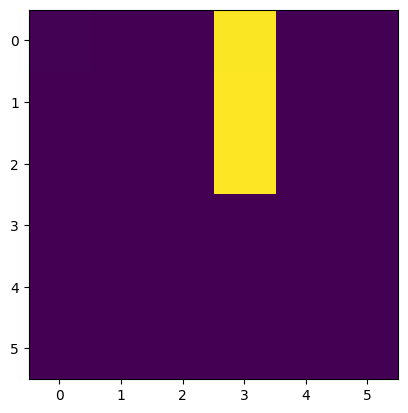

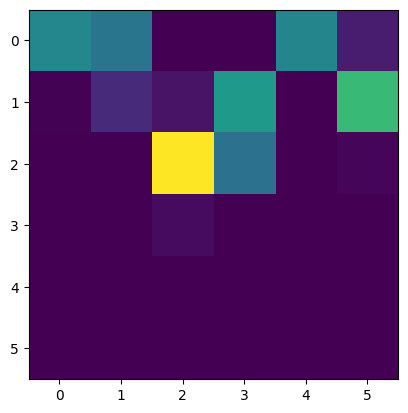

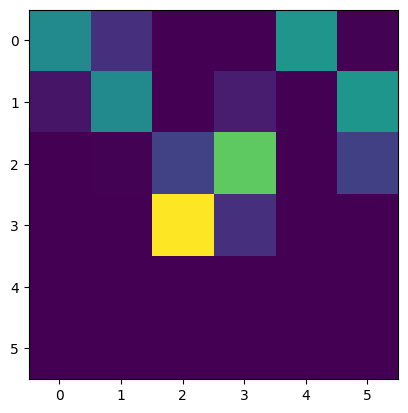

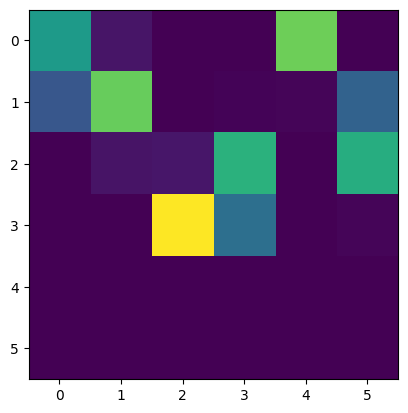

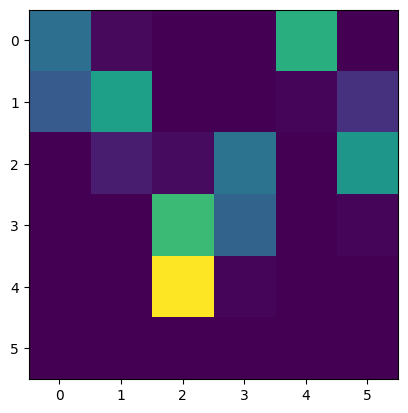

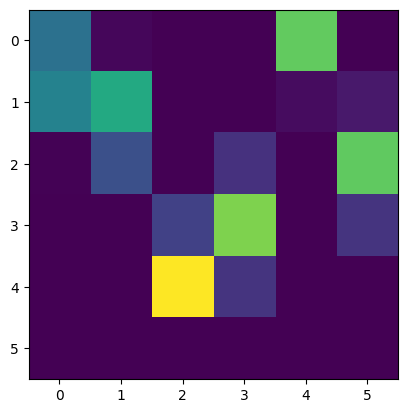

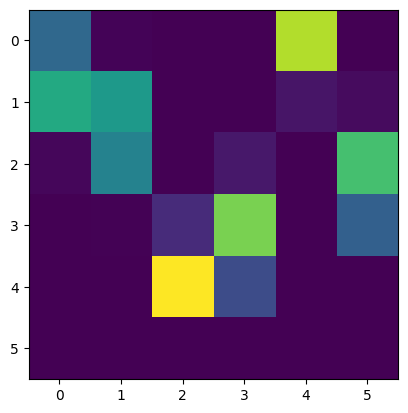

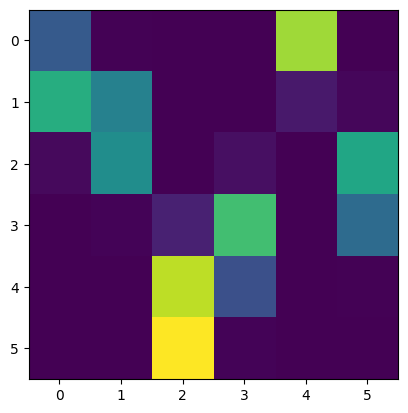

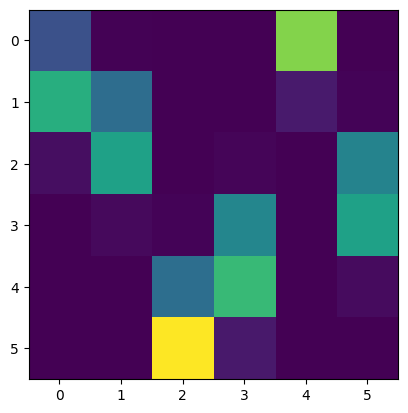

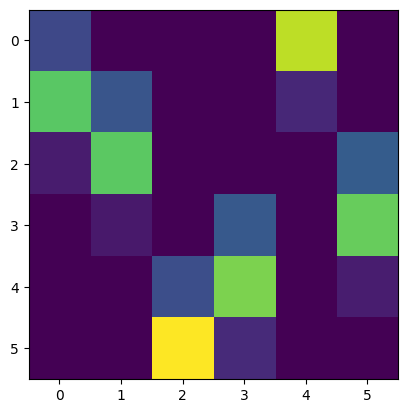

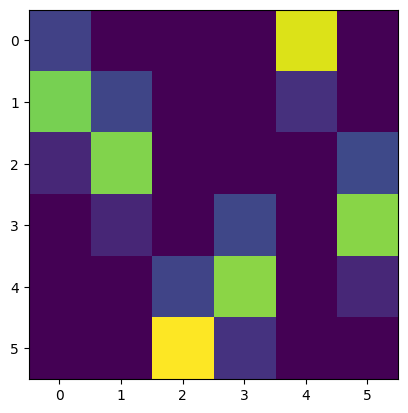

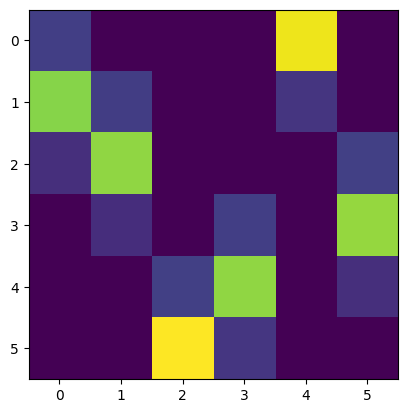

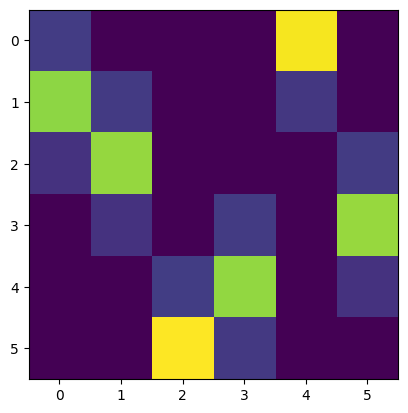

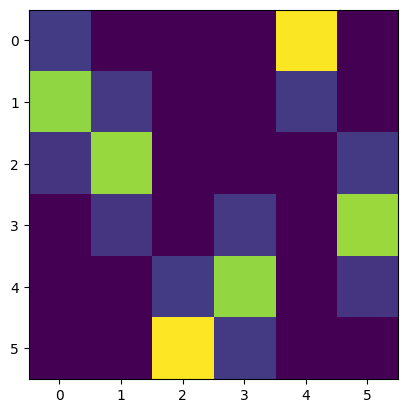

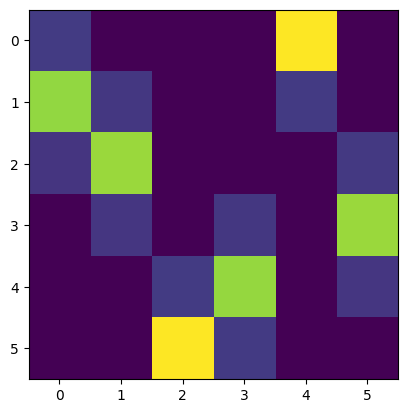

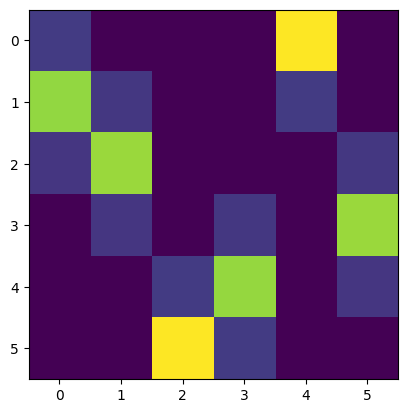

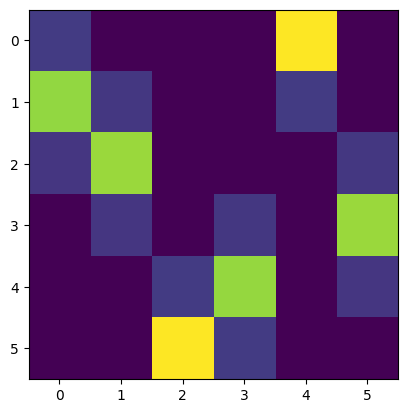

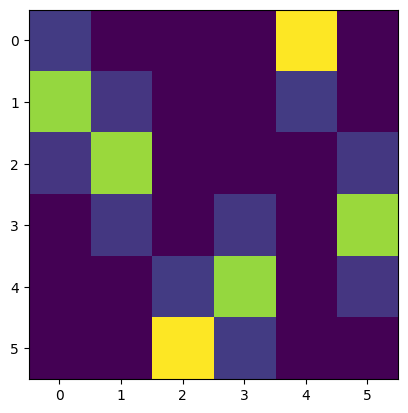

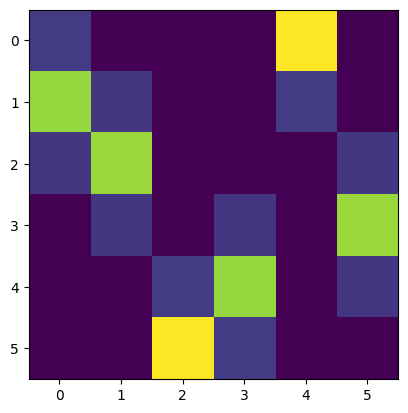

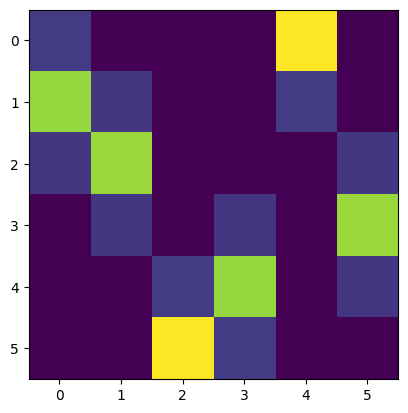

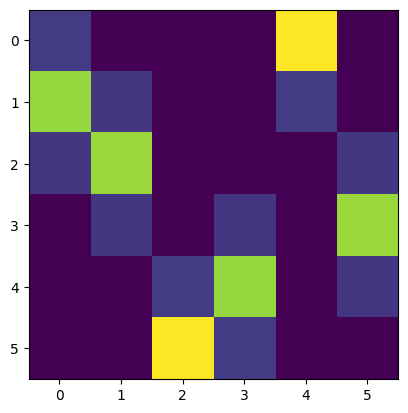

In [3]:
# Z and softmax implementation
from matplotlib import pyplot as plt
n = 6
x = np.random.permutation(n)/float(n)
y = []
for j in range(n):
  y.append(j)
y = np.asarray(y)
x = np.asarray(x)
Z = []
eta = 0.1
Z.append(np.r_[x**2,0])
Z.append(np.r_[x,0])
Z.append(np.r_[y**2,0])
Z.append(np.r_[y,0])
for i in range(3):
  Z.append(np.r_[np.ones(n),0])
Z.append(np.r_[np.ones(n),-1/n])
u = np.random.randn(n)
v = np.random.rand(n)
Z.append(np.r_[u,0])
Z.append(np.r_[v,0])
Z.append(np.r_[np.zeros(n),0])
Z = np.asarray(Z)
Z = Z.T
mp = 11
Q = np.zeros((mp,mp)) #   P^{\ell,1} in the paper 
Q[4,2] = -1
Q[1,3] = 2
Q[0,4] = -1
Q[8,5] = 1
Q[5,6] = -1*float(eta)
Q[6,9] = 1
Q = Q/eta

P = np.zeros((mp,mp)) #  V^{\ell,1} in the paper  
P[7,8] = 1


### Test 1 checking whether the transformer can construct the exp matrix
# A = Z @ Q @ Z.T
# M = A[0:n,0:n]
# onev = np.ones(n)
# A = np.outer(u,onev)
# B = np.outer(onev,v)
# Delta = A + B
# C = np.zeros((n,n))
# for i in range(n):
#   for j in range(n):
#     C[i,j] = (x[i]-y[j])**2
# M2 = (-C + Delta)/eta - 1
# np.linalg.norm(M2-M)

def atten(Z,Q,P):
  A = Z @ Q @ Z.T
  M = np.exp(A)
  sums = np.sum(M,axis=1)
  M = (M.T/sums).T
  return M @ Z @ P

def atten_last(Z,Q):
  A = Z @ Q @ Z.T
  n = Z.shape[0]-1
  B = np.zeros((n+1,n+1))
  B[:,n] = -np.inf
  # B[n,:] = -np.Inf
  M = np.exp(A+B)
  sums = np.sum(M,axis=1)+0.0000001
  M = (M.T/sums).T
  P = np.zeros((mp,mp))
  P[1,10] = 1
  return M[0:n,0:n], M @ Z @ P
# ### Unit Test 2 ### checking whether one head implements updates for u
#onev = np.ones(n)
# A1 = np.outer(u,onev)
# B1 = np.outer(onev,v)
# Delta = A1 + B1
# C = np.zeros((n,n))
# for i in range(n):
#   for j in range(n):
#     C[i,j] = (x[i]-y[j])**2
# M2 = (-C + Delta)/eta - 1
# M1 = -C + Delta
# X = np.exp(M1/eta-1)
# norms = np.sum(X,axis=1) + 1
# D = np.diag(1/norms)
# u1 = u - gamma*D @ (X @ onev-onev/n)
# print(Z1[:,8])
# print(u1)
# D @ X
Q2 = np.zeros((mp,mp)) # P^{(\ell,2)} in the paper 
Q2[4,0] = -1
Q2[3,1] = 2
Q2[2,4] = -1
Q2[9,5] = 1
Q2[5,6] = -1*eta
Q2[6,8] = 1
Q2 = Q2/eta
Z @ Q2
P2 = np.zeros((mp,mp)) # V^{(\ell,2)} in the paper 
P2[7,9] = 1
Z2 = atten(Z,Q2,P2)


# Unit Test 3 ## check whether the transformer implements updates for v
# onev = np.ones(n)
# A1 = np.outer(u,onev)
# B1 = np.outer(onev,v)
# Delta = A1 + B1
# C = np.zeros((n,n))
# for i in range(n):
#   for j in range(n):
#     C[i,j] = (x[i]-y[j])**2
# M2 = (-C + Delta)/eta - 1
# M1 = -C + Delta
# X = np.exp(M1/eta-1)
# A = Z @ Q2 @ Z.T
# P = np.zeros((mp,mp))
# P[7,8] = 1
# M = np.exp(A)
# sums = np.sum(M,axis=1)
# M = (M.T/sums).T
# print(A)
# print(M1/eta-1)
# X = X.T
# norms = np.sum(X,axis=1) + 1
# D = np.diag(1/norms)
# v1 = v - gamma*D @ (X @ onev- onev/n)
# print(v1)
# print(Z2[:,9])
gamma = 0.05
T = 5001
for i in range(T):
  if i % 250 == 0:
    plt.figure()
    attM, Z_last= atten_last(Z,Q2)
    plt.imshow(np.abs(attM))
    name = 'A%i.png' % i
    plt.savefig(name,bbox_inches='tight')
    # files.download(name)
  Z = Z - gamma*atten(Z,Q,P)-gamma*atten(Z,Q2,P2)
print(Z_last[:,mp-1])
print(x)
print(y)

It.  |Err         
-------------------
    0|3.687918e+00|
   10|1.137048e+00|
   20|4.729471e-01|
   30|2.011458e-01|
   40|9.068075e-02|
   50|4.163341e-02|
   60|1.919508e-02|
   70|8.857932e-03|
   80|4.088453e-03|
   90|1.887138e-03|
  100|8.710680e-04|
  110|4.020697e-04|
  120|1.855884e-04|
  130|8.566438e-05|
  140|3.954119e-05|
  150|1.825153e-05|
  160|8.424589e-06|
  170|3.888644e-06|
  180|1.794931e-06|
  190|8.285090e-07|
It.  |Err         
-------------------
  200|3.824254e-07|
  210|1.765209e-07|
  220|8.147900e-08|
  230|3.760929e-08|
  240|1.735980e-08|
  250|8.012982e-09|
  260|3.698653e-09|
  270|1.707234e-09|


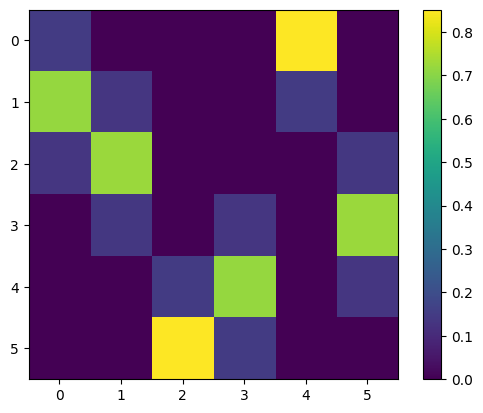

In [6]:
# ploting the optimal transport map (P^*_\lambda in the paper) computed by POT lib;
import ot
a = np.ones(n)
b = np.ones(n)
M = ot.dist(x.reshape((n, 1)), y.reshape((n, 1)))
lambd = eta # note the choice of lambda which is directly connects to eta used to inialize the parameters of the transformer 
Gs = ot.sinkhorn(a, b, M.T, lambd, verbose=True)
plt.figure()
plt.imshow(Gs)
plt.colorbar()



# Figure 2: training the transformer on random inputs
We train a transformer to solve OT in 1-dimension. This code is used to generated Figure 2 in our paper which shows (1) generalization, (2) prompt engineering impact and also (3) iterative inference process across the layers  

In [8]:
# function liberary 
from matplotlib import pyplot as plt
import torch
from torch.autograd import Variable
import numpy as np
from matplotlib import pyplot as plt

dtype =torch.cuda.FloatTensor
def generateZ(ss,n, eta=0.01):
  x = []
  y = []
  opt = []
  for i in range(ss):
    x0 = np.random.permutation(50)[0:n]/float(50)
    y0 = np.zeros(n)
    for j in range(n):
      y0[j] = j/float(n)
    x.append(x0)
    y.append(y0)
    opt.append(torch.tensor(sorted(x0)))
  tensor_opt = torch.stack(opt)
  y = np.asarray(y)
  x = np.asarray(x)
  Y = torch.tensor(y)
  X = torch.tensor(x)
  Zs = []
  out = torch.tensor(y0)
  for j in range(ss):
    x = X[j,:]
    y = Y[j,:]
    Z = []
    Z.append(np.r_[x**2,0])
    Z.append(np.r_[x,0])
    Z.append(np.r_[y**2,0])
    Z.append(np.r_[y,0])
    for i in range(3):
      Z.append(np.r_[np.ones(n),0])
    Z.append(np.r_[np.ones(n),-1/n])
    u = np.random.randn(n)
    v = np.random.rand(n)
    Z.append(np.r_[u,0])
    Z.append(np.r_[v,0])
    Z.append(np.r_[np.zeros(n),0])
    Z = np.asarray(Z)
    Z = torch.tensor(Z).type(dtype)
    Z = Z.T
    Zs.append(Z)
  return torch.stack(Zs), tensor_opt.type(dtype)

def get_params(mp,optim = True):
  params = []
  params_np = []
  if optim:
    Q = np.zeros((mp,mp))
    Q[4,2] = -1
    Q[1,3] = 2
    Q[0,4] = -1
    Q[8,5] = 1
    Q[5,6] = -1*float(eta)
    Q[6,9] = 1
    Q = Q/eta
  else:
    Q = np.random.randn(mp,mp)/(2*np.sqrt(mp))
  params_np.append(Q)
  Q =  Variable(torch.tensor(Q).type(dtype),requires_grad = True)
  params.append(Q)
  if optim:
    P = np.zeros((mp,mp))
    P[7,8] = 1
  else:
    P = np.random.randn(mp,mp)/(2*np.sqrt(mp))
    # P = np.zeros((mp,mp))
    # P[7,8] = 1
  params_np.append(P)
  P = Variable(torch.tensor(P).type(dtype),requires_grad = True)
  params.append(P)
  if optim:
    Q2 = np.zeros((mp,mp))
    Q2[4,0] = -1
    Q2[3,1] = 2
    Q2[2,4] = -1
    Q2[9,5] = 1
    Q2[5,6] = -1*eta
    Q2[6,8] = 1
    Q2 = Q2/eta
  else:
    Q2 = np.random.randn(mp,mp)/np.sqrt(mp)
  params_np.append(Q2)
  Q2 = Variable(torch.tensor(Q2).type(dtype),requires_grad = True)
  params.append(Q2)
  if optim:
    P2 = np.zeros((mp,mp))
    P2[7,9] = 1
  else:
    P2 = np.random.randn(mp,mp)/np.sqrt(mp)
    # P2 = np.zeros((mp,mp))
    # P2[7,9] = 1
  params_np.append(P2)
  P2 = Variable(torch.tensor(P2).type(dtype),requires_grad = True)
  params.append(P2)
  return params,params_np


def atten_tr(Z, Q,P):
  A = torch.einsum('nij,jk,nmk->nim',(Z, Q,Z))
  M = torch.exp(A)
  M = torch.nn.functional.normalize(M,dim=2,p=1)
  return  torch.einsum('nij,njk,km->nim',(M,Z,P))

def atten_last_tr(Z_tr,params,mp):
  A = torch.einsum('nij,jk,nmk->nim',(Z_tr, params[0],Z_tr))
  n = Z_tr.size(1)-1
  ss = Z_tr.size(0)
  B = np.zeros((ss,n+1,n+1))
  B[:,:,n] = float('-inf')
  M = torch.exp(A+torch.tensor(B).type(dtype))
  mp = Z_tr.size(2)
  P = np.zeros((mp,mp))
  P[1,mp-1] = 1.0
  P = torch.tensor(P).type(dtype)
  M = torch.nn.functional.normalize(M,dim=2,p=1,eps=0)
  return torch.einsum('nij,njk,km->nim',(M,Z_tr,P))

def optimize(layers,generateZ,optim,n,mp, lr=0.001,gamma=0.1,T= 10000,ss=500):
  nlay = len(layers)
  Z_tr,tensor_opt = generateZ(ss,n)
  for i in range(T):
    Z0 = Z_tr.clone()
    for j in range(nlay-1): # nlay-1
      A1 = atten_tr(Z0,layers[j][0],layers[j][1])
      A2 = atten_tr(Z0,layers[j][2],layers[j][3])
      Z0 = Z0 - gamma*A1 - gamma*A2
    Z0 = atten_last_tr(Z0,layers[nlay-1],mp)
    loss = torch.mean(torch.square(Z0[:,0:n,mp-1]-tensor_opt))
    if i % 50 ==0:
      Z_tr,tensor_opt = generateZ(ss,n)
    if i % 1000 ==0:
      print(loss.item())
    optim.zero_grad()
    loss.backward()
    optim.step()
  return layers

def optimize_shared(layers,generateZ,optim,n,mp, lr=0.001,gamma=0.1,T= 10000,ss=500):
  nlay = len(layers)
  Z_tr,tensor_opt = generateZ(ss,n)
  for i in range(T):
    Z0 = Z_tr.clone()
    for j in range(nlay-1): # nlay-1
      A1 = atten_tr(Z0,layers[0][0],layers[0][1])
      A2 = atten_tr(Z0,layers[0][2],layers[0][3])
      Z0 = Z0 - gamma*A1 - gamma*A2
    Z0 = atten_last_tr(Z0,layers[nlay-1],mp)
    loss = torch.mean(torch.square(Z0[:,0:n,mp-1]-tensor_opt))
    if i % 50 ==0:
      Z_tr,tensor_opt = generateZ(ss,n)
    if i % 1000 ==0:
      print(loss.item())
    optim.zero_grad()
    loss.backward()
    optim.step()
  return layers

def compute_loss(layers,n,mp,Z,tensor_opt,gamma):
  nlay = len(layers)-1
  Z0 = Z.clone()
  for j in range(nlay-1):
    Q0 = layers[j][0]
    P0 = layers[j][1]
    Q1 = layers[j][2]
    P1 = layers[j][3]
    A1 = atten_tr(Z0,Q0,P0)
    A2 = atten_tr(Z0,Q1,P1)
    Z0 = Z0 - gamma*A1 - gamma*A2
  Z0 = atten_last_tr(Z0,layers[nlay],mp)
  loss = torch.mean(torch.square(Z0[:,0:n,mp-1]-tensor_opt))
  return loss


In [9]:
# training on random samples
def train(mp,generateZ,gamma,ss  = 5000,T = 5000,lr = 0.001, n = 5, nlay = 15):
  layers = []
  for i in range(nlay):
    params, params_np = get_params(mp,optim = False) # creating parameters
    layers.append(params)
  # collecting all the parameters in a list
  param = [] # the list of parameters
  for i in range(nlay):
    param = param + layers[i]#[layers[i][0]]
    param = param + layers[i]#[layers[i][2]]
  # optimization method
  optim = torch.optim.Adam(param,lr=lr )
  gamma = 0.1
  layers = optimize(layers,generateZ,optim,n,mp,lr,gamma,T,ss)
  return layers



In [12]:
def atten_pattern_tr(Z_tr,params,ind=0):
  mp = Z_tr.size(2)
  A = torch.einsum('nij,jk,nmk->nim',(Z_tr, params[ind],Z_tr))
  n = Z_tr.size(1)-1
  ss = Z_tr.size(0)
  B = np.zeros((ss,n+1,n+1))
  B[:,:,n] = float('-inf')
  M = torch.exp(A+torch.tensor(B).type(dtype))
  mp = Z_tr.size(2)
  P = np.zeros((mp,mp))
  P[1,mp-1] = 1.0
  P = torch.tensor(P)
  M = torch.nn.functional.normalize(M,dim=2,p=1,eps=0)
  return M
def generate_plots(Z_tr_test,layers,n,gamma,xind):
  nlay = len(layers)
  Z0 = Z_tr_test.clone()
  for j in range(nlay-1): #nlay-1
    ptr = atten_pattern_tr(Z0,layers[nlay-1],ind=0)[0,0:n,0:n]
    Q0 = layers[j][0]
    P0 = layers[j][1]
    Q1 = layers[j][2]
    P1 = layers[j][3]
    A1 = atten_tr(Z0,Q0,P0)
    A2 = atten_tr(Z0,Q1,P1)
    Z0 = Z0 - gamma*A1 - gamma*A2
    if j % 2 == 0:
      plt.figure()
      plt.imshow(ptr.cpu().detach().numpy())
      plt.colorbar()
      name = 'att%d.pdf' % j
      plt.savefig(name)
      # files.download(name)
  ptr = atten_pattern_tr(Z0,layers[nlay-1],ind=0)[0,0:n,0:n]
    # if j % 1 == 0:
  plt.figure()
  plt.imshow(ptr.cpu().detach().numpy())
  plt.colorbar()
  name = 'att_last_withE.pdf'
  plt.savefig(name,format='pdf',bbox_inches='tight')
  # files.download(name)

  x0 = Z_tr_test[0,0:n,xind].cpu().detach().numpy()
  inds = np.argsort(x0)
  P = np.zeros((n,n))
  for i in range(n):
    P[i,inds[i]] = 1
  plt.figure()
  plt.imshow(P)
  plt.colorbar()
  name = 'ground.pdf'
  plt.savefig(name,format='pdf',bbox_inches='tight')
  # files.download(name)
def compute_error(Z_tr_test,layers,n,gamma,xind):
  nlay = len(layers)
  Z0 = Z_tr_test.clone()
  x0 = Z_tr_test[0,0:n,xind].cpu().detach().numpy()
  inds = np.argsort(x0)
  P = np.zeros((n,n))
  for i in range(n):
    P[i,inds[i]] = 1
  for j in range(nlay-1): #nlay-1
    ptr = atten_pattern_tr(Z0,layers[nlay-1],ind=0)[0,0:n,0:n]
    Q0 = layers[j][0]
    P0 = layers[j][1]
    Q1 = layers[j][2]
    P1 = layers[j][3]
    A1 = atten_tr(Z0,Q0,P0)
    A2 = atten_tr(Z0,Q1,P1)
    Z0 = Z0 - gamma*A1 - gamma*A2
    if j % 2 == 0:
      print(np.linalg.norm(ptr.cpu().detach().numpy()-P.T),np.max(ptr.cpu().detach().numpy()))
      # files.download(name)


In [16]:
# script to train the model (note that sometimes the training optimization just diverages) 
gamma=0.1
lr = 0.0005
T = 5001
n = 7
torch.manual_seed(10001)
layers = train(11,generateZ,ss  = 1000,T = T,gamma=gamma,lr = lr, n=n, nlay = 20)

0.21380086243152618
0.002876959042623639
0.0008781517972238362
0.00033452361822128296
0.00018678388732951134
0.0001292828965233639


*ploting* the attention heat map across the layers and the last generated plots the OT solution computed by OT lib. We first test extracting OT with attention for n=7 which is the same size for training and then test it for n=15 to show the **generalization** in *Figure 2.a*

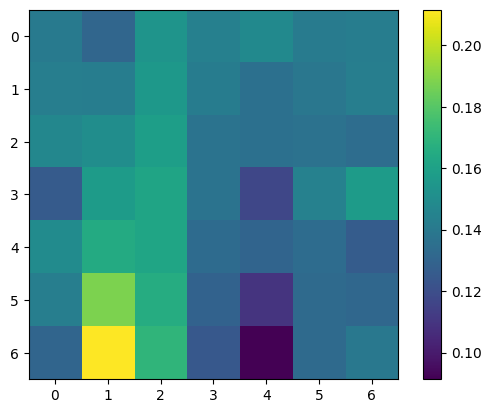

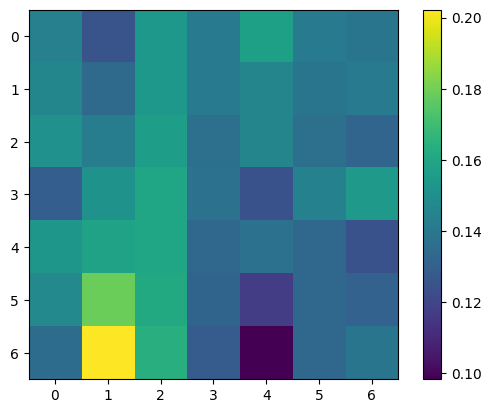

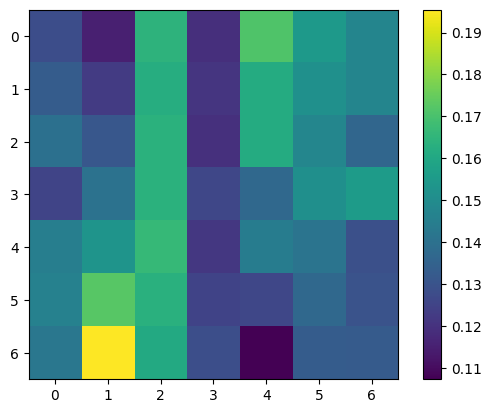

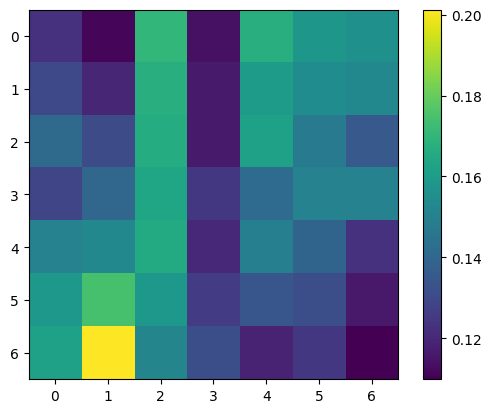

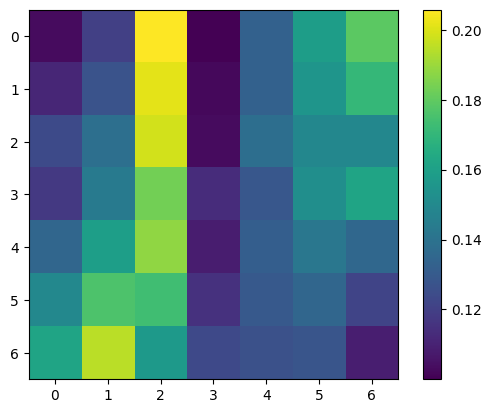

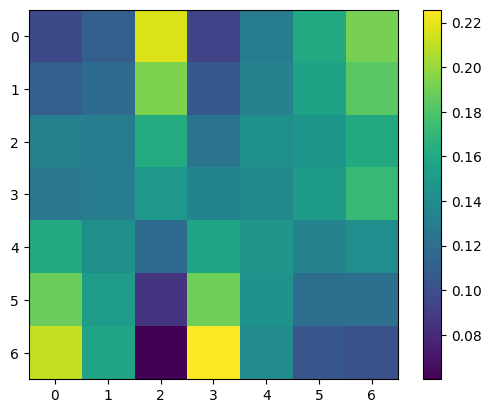

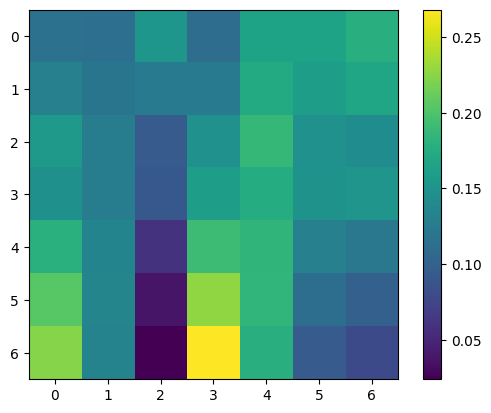

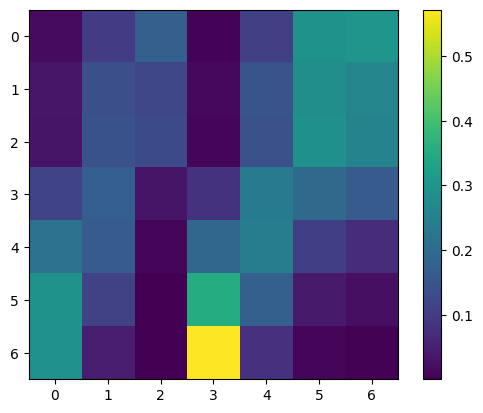

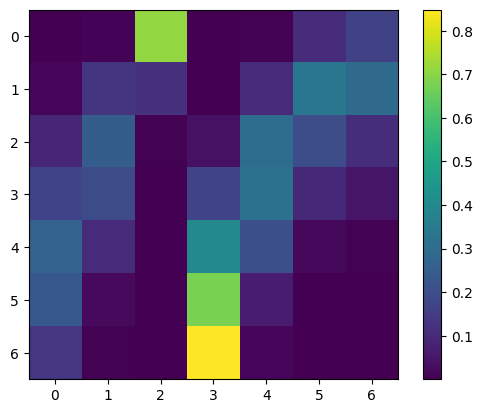

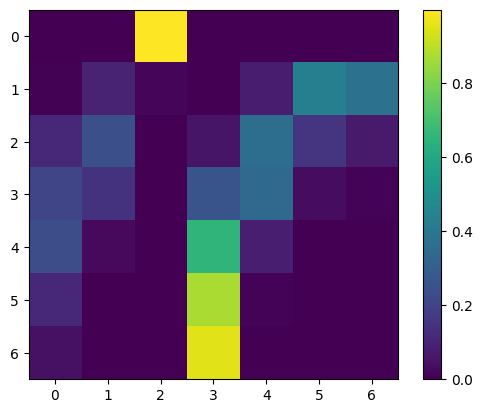

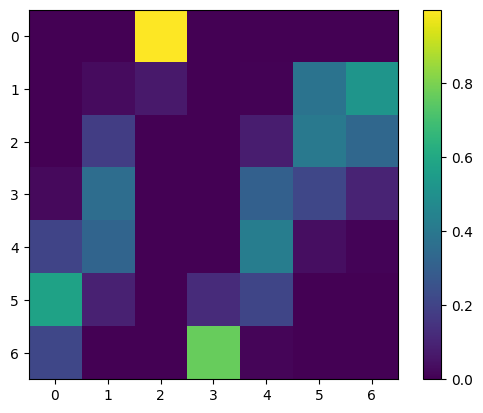

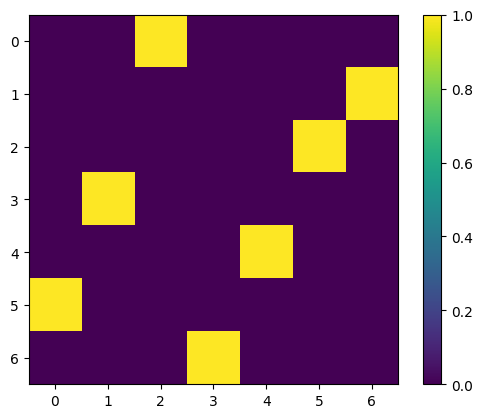

In [17]:
# ploting the attention heat map across the layers (the last generated plots the OT solution computed by OT lib) 
Z_tr_test,tensor_opt = generateZ(1,7)
generate_plots(Z_tr_test,layers,7,gamma,xind=1)

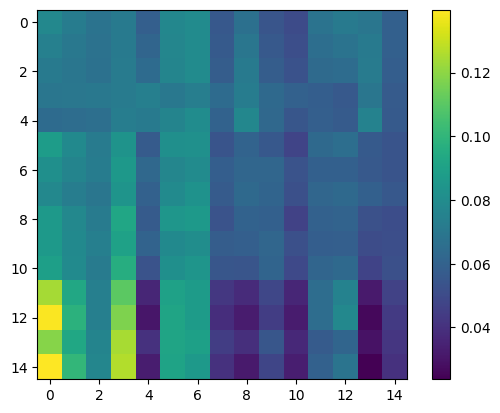

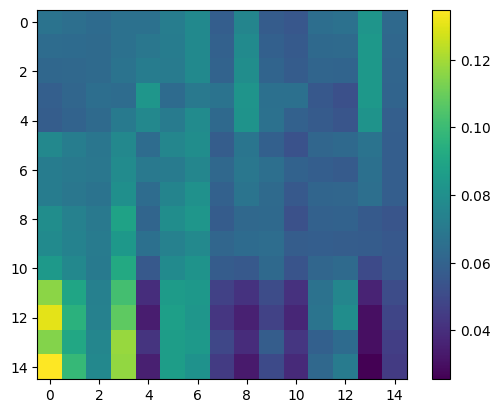

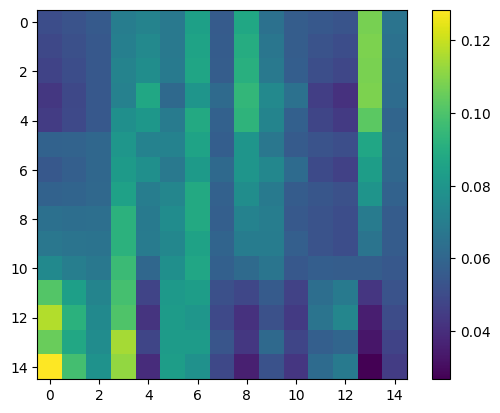

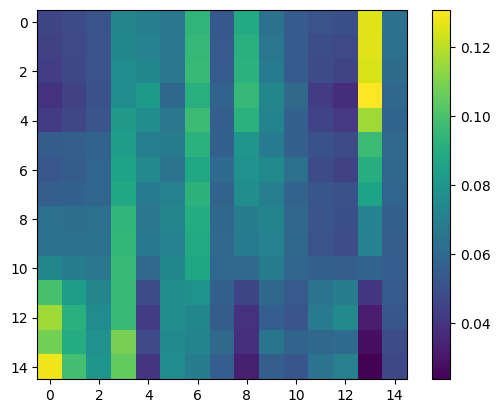

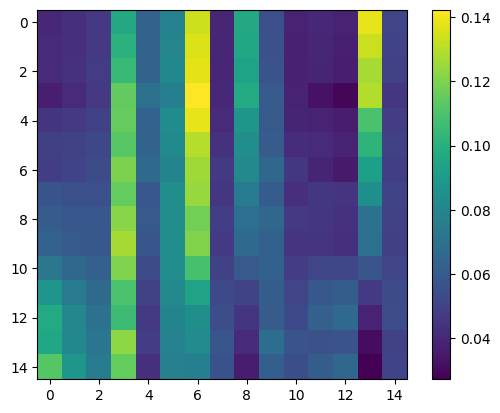

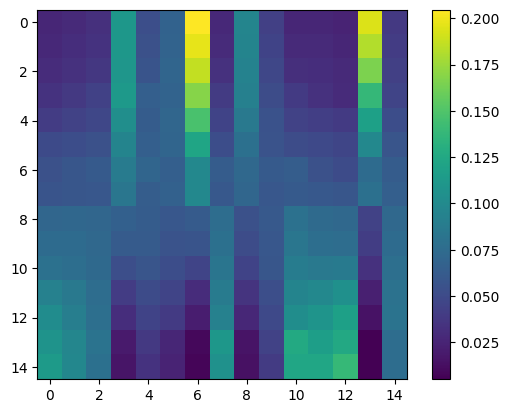

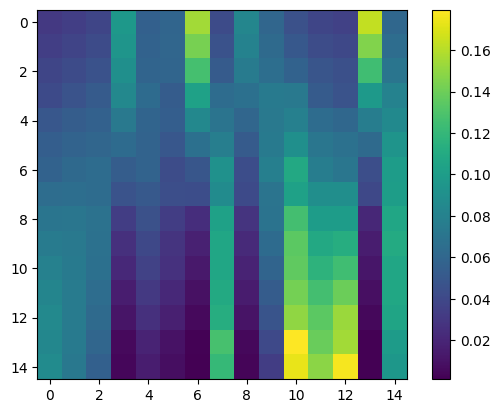

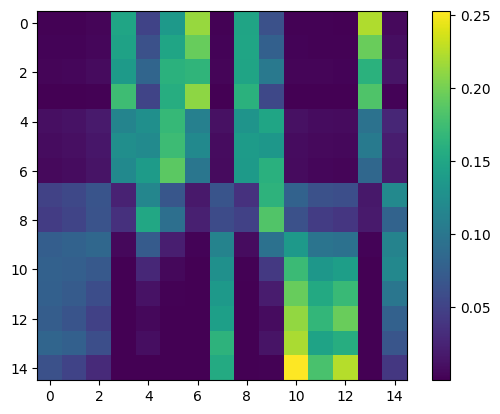

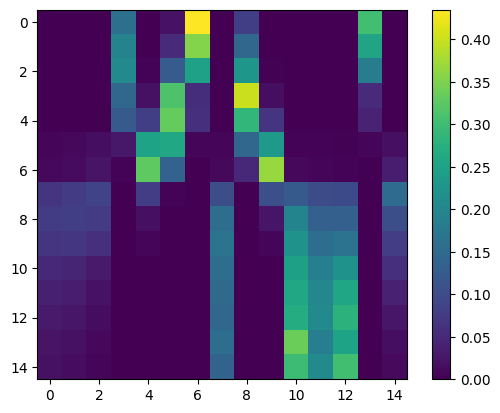

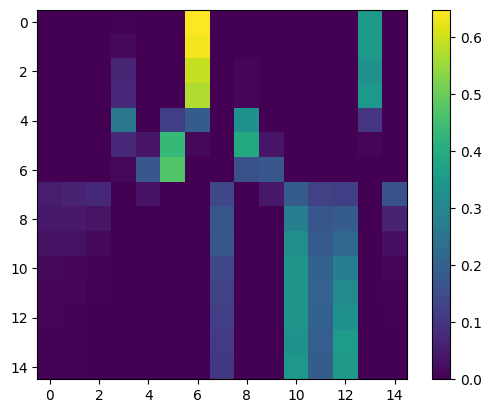

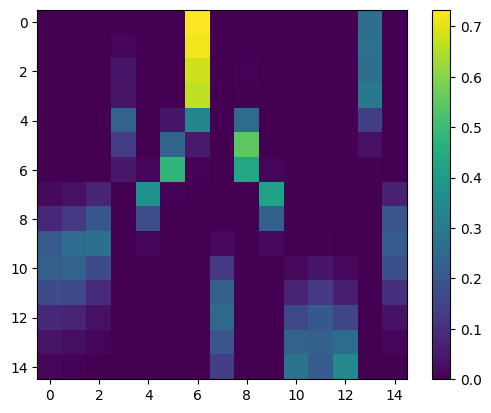

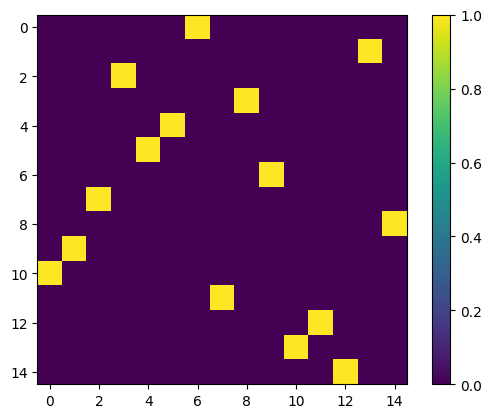

In [18]:
Z_tr_test,tensor_opt = generateZ(1,15)
generate_plots(Z_tr_test,layers,15,gamma,xind=1)

# Figure 2.b: Prompt Engineering 
We remove the engineering part of the input to check its influence in solving OT. 

In [20]:
def get_truncated_Z(ss,n, eta=0.01):
  x = []
  y = []
  opt = []
  for i in range(ss):
    x0 = np.random.permutation(50)[0:n]/float(50)
    y0 = np.zeros(n)
    for j in range(n):
      y0[j] = j/float(n)
    x.append(x0)
    y.append(y0)
    opt.append(torch.tensor(sorted(x0)))
  tensor_opt = torch.stack(opt)
  y = np.asarray(y)
  x = np.asarray(x)
  Y = torch.tensor(y)
  X = torch.tensor(x)
  Zs = []
  out = torch.tensor(y0)
  for j in range(ss):
    x = X[j,:]
    y = Y[j,:]
    Z = []
    Z.append(x)
    Z.append(y)
    Z.append(np.zeros(n))
    Z = np.asarray(Z)
    Z = torch.tensor(Z).type(dtype)
    Z = Z.T
    Zs.append(Z)
  return torch.stack(Zs), tensor_opt.type(dtype)

def truncated_Z(ss,n,X,Y, eta=0.01): # this function removes prompt engineering
  Zs = []
  ss = X.shape[0]
  n = X.shape[1]
  for j in range(ss):
    x = X[j,:]
    y = Y[j,:]
    Z = []
    Z.append(x)
    Z.append(y)
    Z.append(np.zeros(n))
    Z = np.asarray(Z)
    Z = torch.tensor(Z).type(dtype)
    Z = Z.T
    Zs.append(Z)
  return torch.stack(Zs), tensor_opt.type(dtype)

In [22]:
# training 
torch.manual_seed(10001)
layers_tr = train(3,get_truncated_Z,ss  = 1000,T = T,gamma=gamma,lr = lr, n = n, nlay = 20)

0.1607733517885208
0.03985447436571121
0.004991530440747738
0.0047053867019712925
0.004451123531907797
0.004248041193932295


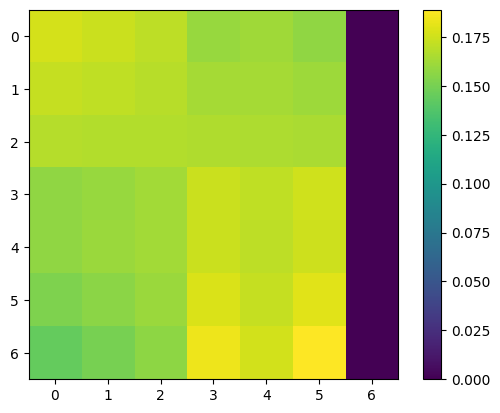

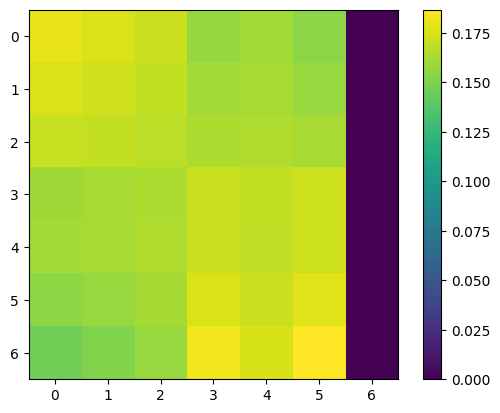

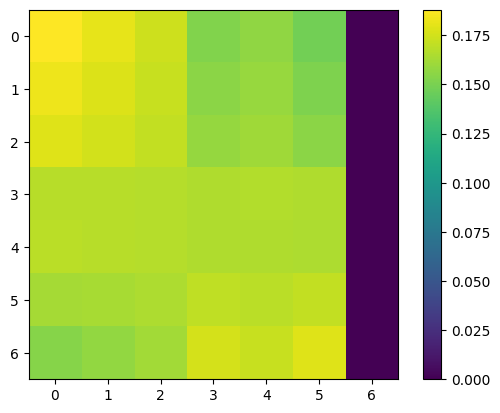

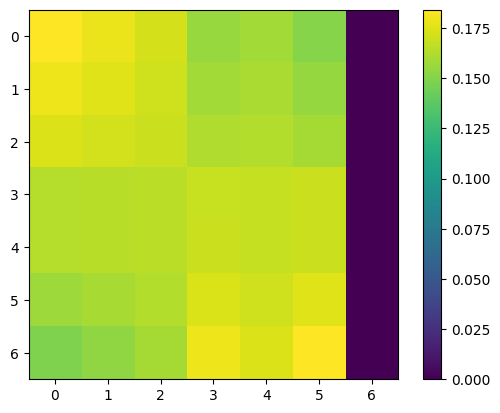

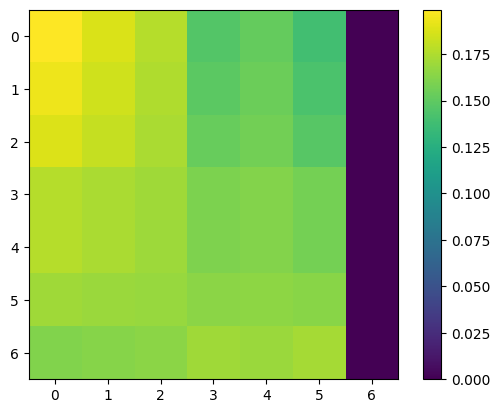

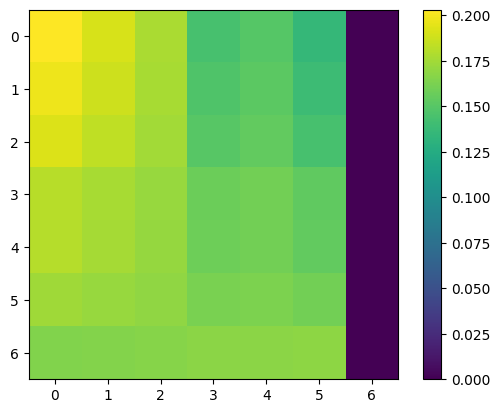

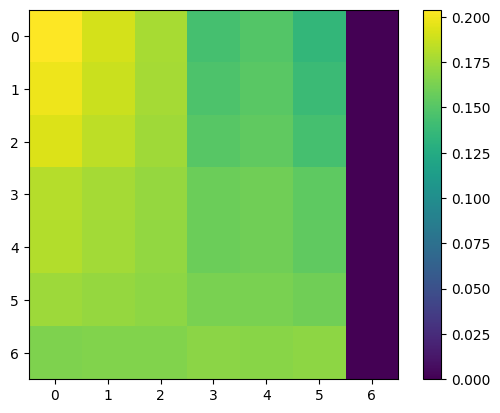

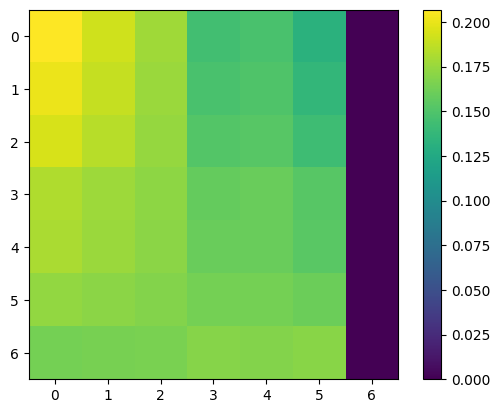

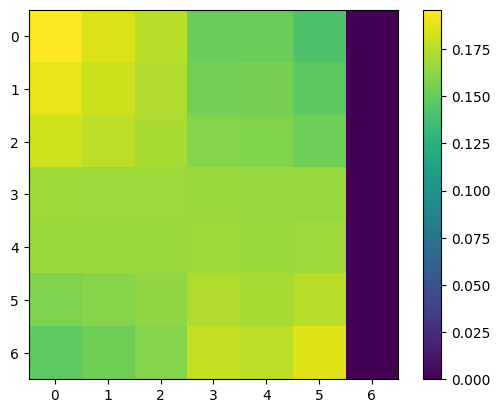

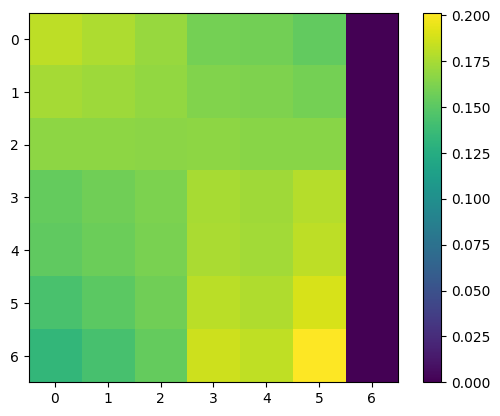

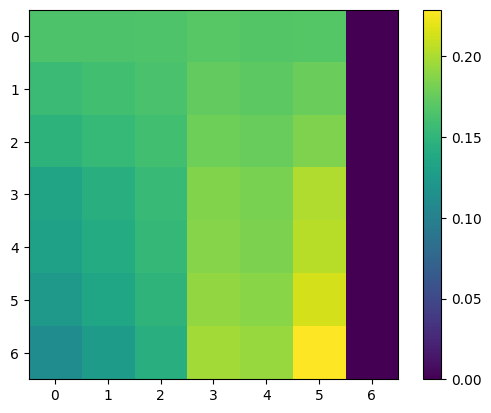

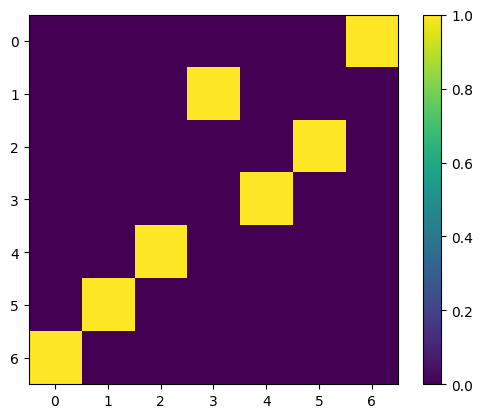

In [23]:
# plotting 
n = 7
Z1,_ = truncated_Z(1,n,Z_tr_test[:,0:n,1].detach().cpu().numpy(),Z_tr_test[:,0:n,3].detach().cpu().numpy())
generate_plots(Z1,layers_tr,n,gamma,xind=0)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

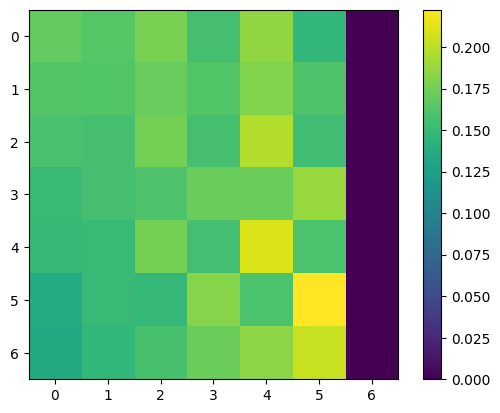

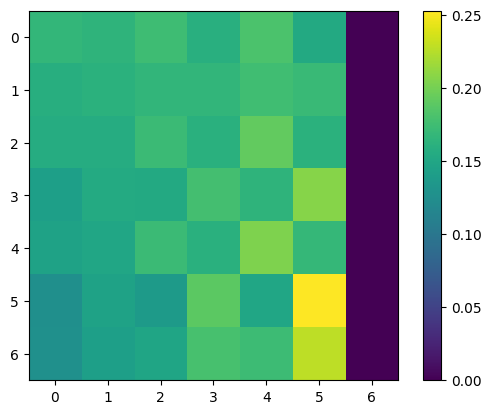

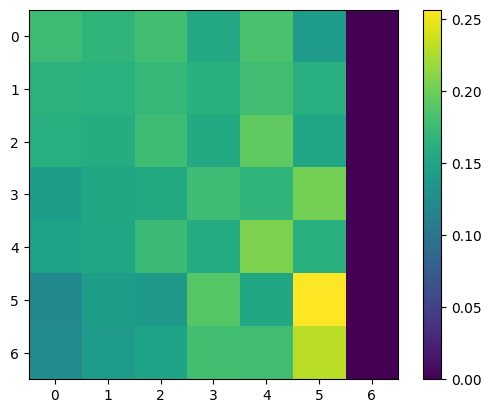

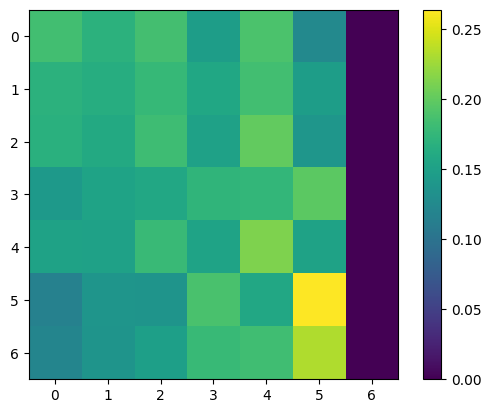

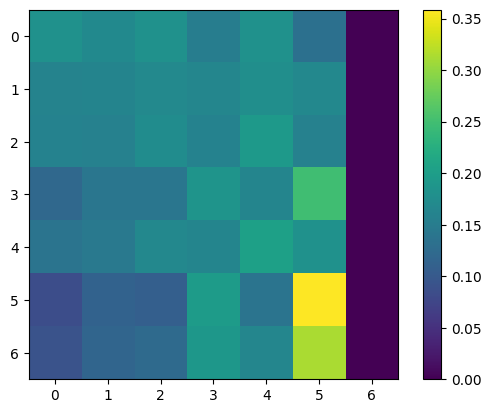

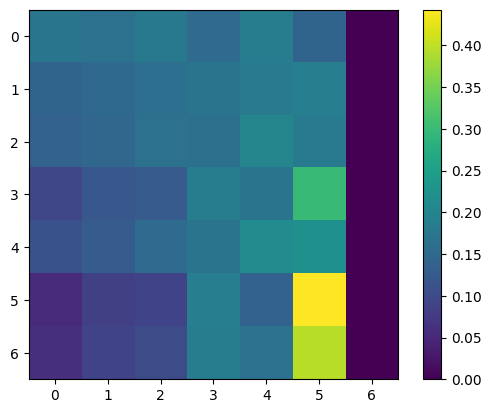

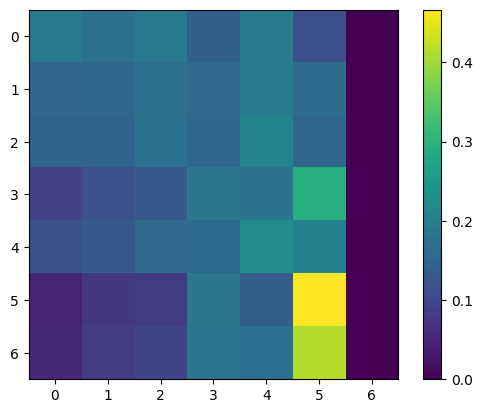

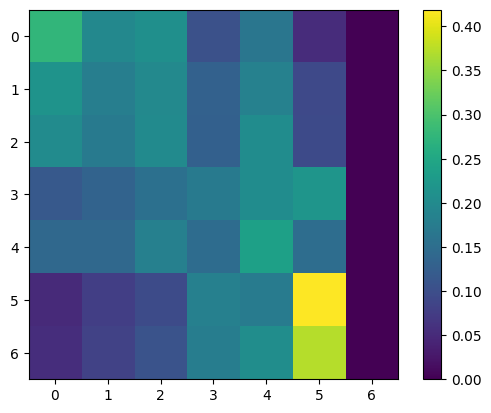

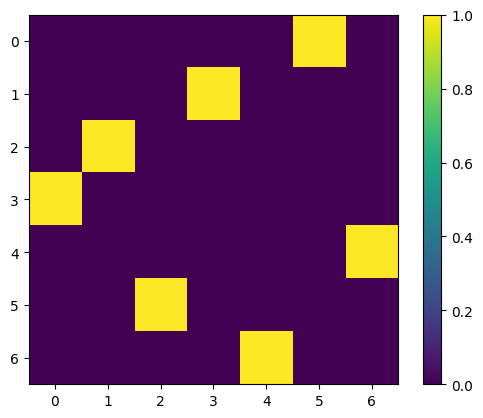

In [ ]:
Z1,_ = truncated_Z(1,n,Z_tr_test[:,0:n,1].detach().cpu().numpy(),Z_tr_test[:,0:n,3].detach().cpu().numpy())
generate_plots(Z1,layers_tr,n,gamma,xind=0)